# Code Execution Agent with LLM : Password Strength Checker

# Concept
An intelligent code execution agent that leverages LLM to analyze password strength and provide security recommendations

## Technical Stack
- Uses Together.ai's LLaMA model for code generation
- Executes code safely in e2b sandbox environment

## Why Sandbox Environment?
We use a sandbox environment [e2b](https://e2b.dev/) to safely execute LLM-generated code in an isolated container, protecting against potentially harmful code while ensuring consistent execution.

# Flow Chart
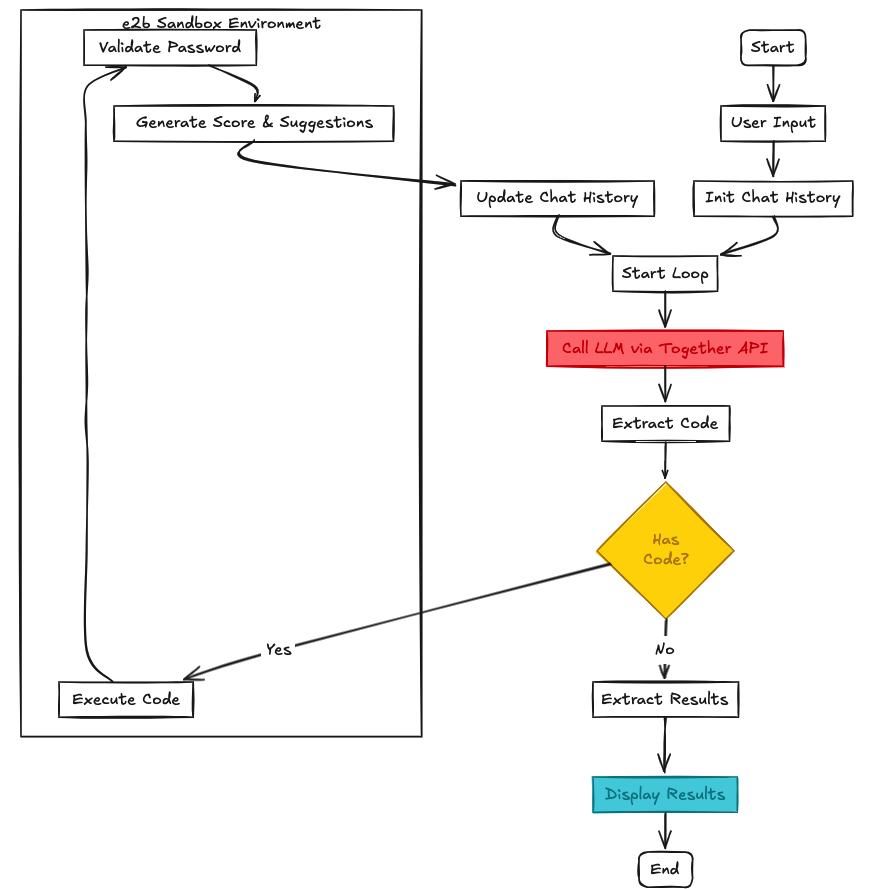

In [ ]:
! pip install e2b_code_interpreter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.7/81.7 kB 2.6 MB/s eta 0:00:00


 ## Import Dependencies

In [ ]:
from openai import OpenAI
from google.colab import userdata, files
from e2b_code_interpreter import Sandbox
import re
from IPython.display import display, Image as IPImage

## Helper Functions

In [ ]:
# Extract code blocks function
def extract_code_block(text):
    pattern = r'```(\w*)\n(.*?)```'
    match = re.search(pattern, text, re.DOTALL)

    if not match:
        return None, None

    language = match.group(1).lower() or None
    code_content = match.group(2).strip()

    return language, code_content

## API Setup

In [ ]:
# Setup client
client = OpenAI(
  api_key=userdata.get("TOGETHER_API_KEY"),
  base_url="https://api.together.xyz/v1",
)

In [ ]:
# Define list of passwords to test
passwords = [
    "password123",
    "Welcome2024!",
    "C0mpl3x#2024",
    "Ab1!"
]

## Sandbox Environment

In [ ]:
sbx = Sandbox(api_key=userdata.get("E2B_API_KEY"))

## Chat History Configuration

In [ ]:
chat_history = [
    {"role": "system", "content": """
    You are a Password Strength Checker. Generate Python code that:
    1. Checks password strength against common rules
    2. Provides detailed feedback on what rules pass/fail
    3. Suggests improvements if needed
    4. Uses regex for pattern matching
    5. Calculates and displays an overall strength score
    """},
    {"role": "user", "content": f"Check these passwords against rules (8+ chars, uppercase, number, symbol): {passwords}"}
]

In [ ]:
while True:
    completion = client.chat.completions.create(
        model="meta-llama/Llama-3.3-70B-Instruct-Turbo-Free",
        messages=chat_history
    )
    # Get LLM response
    response = completion.choices[0].message.content
    print(response)
    chat_history.append({"role": "system", "content": response})

    # Extract and execute code
    language, code = extract_code_block(response)

    # Handle results and continue conversation
    if code:
        execution = sbx.run_code(code)
        print(execution.logs.stdout)
        chat_history.append({
            "role": "assistant",
            "content": "Analyze the results and suggest improvements for weak passwords."
        })
        if execution.error:
            print(execution.error)
            chat_history.append({
                "role": "assistant",
                "content": execution.error
            })
    else:
        break
# Cleanup
sbx.kill()

```python
import re

def check_password_strength(password):
    """
    Checks password strength against common rules and provides feedback.
    
    Args:
    password (str): The password to check.
    
    Returns:
    dict: A dictionary containing the password strength score and feedback.
    """
    
    # Initialize the score and feedback
    score = 0
    feedback = {
        "length": False,
        "uppercase": False,
        "number": False,
        "symbol": False
    }
    
    # Check the length of the password
    if len(password) >= 8:
        score += 1
        feedback["length"] = True
    
    # Check for uppercase letters
    if re.search(r"[A-Z]", password):
        score += 1
        feedback["uppercase"] = True
    
    # Check for numbers
    if re.search(r"\d", password):
        score += 1
        feedback["number"] = True
    
    # Check for symbols
    if re.search(r"[^A-Za-z0-9]", password):
        score += 1
        feedback["symbol"] = True
    
    # Cal